In [1]:
import requests
import numpy as np
import pandas as pd
from datetime import datetime
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'numpy'

In [2]:
my_key='722729cfa99e33f0f76a6c4385beb4a6394f1728'

## US Census: Finding variable code (ie B01003_001E for total population)
When you’re trying to web-scrape a Census variable, the safest way is to check the official variables.json metadata file (for example: https://api.census.gov/data/2024/acs/acs1/subject/variables.json) and search for keywords to find the exact variable code.    
It’s also totally fine to start from the Census website table itself: just look at the table name, identify which row and column your data lives in, and then map that position to the corresponding variable code.

## Function to fetch multiple variables from United States Census Bureau

In [3]:
def fetch_msa_variable_acs1_recent_n_years(var_code: list, var_name: list, api_key: str, n_years: int, max_lookback: int = 10):
    """
    Fetch one ACS1 variable for all MSAs for the most recent n available years.
    """

    current_year = datetime.today().year
    dfs = []
    collected = 0

    for year in range(current_year, current_year - max_lookback, -1):

        if collected >= n_years:
            break

        # determine endpoint
        if var_code.startswith("S"):
            base_url = f"https://api.census.gov/data/{year}/acs/acs1/subject"
        elif var_code.startswith("B"):
            base_url = f"https://api.census.gov/data/{year}/acs/acs1"
        elif var_code.startswith("D"):
            base_url = f"https://api.census.gov/data/{year}/acs/acs1/profile"
        else:
            raise ValueError("Unsupported variable code prefix")

        params = {
            "get": f"NAME,{var_code}",
            "for": "metropolitan statistical area/micropolitan statistical area:*",
            "key": api_key
        }

        response = requests.get(base_url, params=params)

        if response.status_code != 200:
            continue

        data = response.json()

        if len(data) <= 1:
            continue

        df = pd.DataFrame(data[1:], columns=data[0])

        if var_code not in df.columns:
            continue

        df = df.rename(columns={
            var_code: var_name,
            "NAME": "msa_name",
            "metropolitan statistical area/micropolitan statistical area": "msa_code"
        })

        df[var_name] = pd.to_numeric(df[var_name], errors="coerce")
        df["year"] = year

        dfs.append(df[["msa_code", "msa_name", "year", var_name]])
        collected += 1

    if not dfs:
        raise RuntimeError("No available data found")

    return pd.concat(dfs, ignore_index=True)

In [ ]:
# collect useful variables their codes to this dictionary.
variables_acs1 = {"Total_Population": "B01003_001E",
                  "Laborforce_Population": "DP03_0002E",
                  "Employed": "DP03_0004E",
                  "Median_Household_Income": "S1903_C03_001E",
                  "Median_House_Value": "B25077_001E",
                  "Total_Housing_Units": "B25002_001E",
                  "House_Occupied": "B25002_002E",
                  "House_Vacant": "B25002_003E",
                  "Median_Gross_Rent": "B25064_001E"
                 }

In [ ]:
# Model instantiation: Fetch ACS1 variables for all MSAs for the most recent n+1 available years.
# n+1 years of data is needed to construct growh factors, i.e. population growth
dfs = []
for var_name, var_code in variables_acs1.items():
  df = fetch_msa_variable_acs1_recent_n_years(var_code = var_code, var_name = var_name, api_key = my_key, n_years = 5+1)
  dfs.append(df)

In [ ]:
msa_features_recent_5_years = reduce(lambda left, right: pd.merge(
        left, right, on=["msa_code", "msa_name", "year"], how="outer"), dfs)
msa_features_recent_5_years = msa_features_recent_5_years.sort_values(by=['msa_code', 'year'])

# Filter out MSAs with a total population over 300,000 by the most recent year
population_requirement=300000

most_recent_year = msa_features_recent_5_years['year'].max()
eligible_msa = msa_features_recent_5_years.loc[
    (msa_features_recent_5_years['year'] == most_recent_year) &
    (msa_features_recent_5_years['Total_Population'] >= population_requirement) &
    (msa_features_recent_5_years['msa_name'].str.endswith('Metro Area')),
    'msa_code'].unique()

msa_features_recent_5_years = msa_features_recent_5_years[
    msa_features_recent_5_years['msa_code'].isin(eligible_msa)]

# Print out the number of MSAs achieving population requirement
print(f"By the year {most_recent_year}, {msa_features_recent_5_years['msa_code'].nunique()} \
MSAs have a population of over {population_requirement}.")

By the year 2024, 173 MSAs have a population of over 300000.


In [ ]:
# Note that the U.S. Census Bureau did not release standard 2020 American Community Survey (ACS) 1-year estimates
# because the COVID-19 pandemic severely disrupted data collection, leading to low response rates and high nonresponse bias.
# If it is extremely necessary to use consecutive data including 2020, we shall switch from acs1 to acs5.
msa_features_recent_5_years[msa_features_recent_5_years['msa_code']=='16980']

,msa_code,msa_name,year,Total_Population,Laborforce_Population,Employed,Median_Household_Income,Median_House_Value,Total_Housing_Units,House_Occupied,House_Vacant,Median_Gross_Rent
512,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2018,9497790,5089589,4792415,70760,247800,3858653,3538101,320552,1110
513,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2019,9457867,5059338,4796817,75379,253800,3869464,3539174,330290,1139
514,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2021,9510390,5063933,4663627,78166,281100,3956161,3670416,285745,1225
515,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2022,9442159,5097936,4833113,82914,301300,3968906,3726266,242640,1294
510,16980,"Chicago-Naperville-Elgin, IL-IN Metro Area",2023,9262559,5053959,4791844,87071,316500,3911902,3671659,240243,1390
511,16980,"Chicago-Naperville-Elgin, IL-IN Metro Area",2024,9406924,5137844,4840603,90770,339700,3924020,3690402,233618,1469


## Joining US Census data with tax data (Updated)
While US census data are collected on MSA scale, tax data are collected on different scales, using **Gemini**:    
- Residential Effective Rate: State Averaged
- Commercial Effective Rate: proxy of the Largest City of that State

To merge the two datasets in a consistent manner, we assign each MSA the state code corresponding to the state in which its largest principal city (the 1st city in MSA title) is located. We then use this state code to merge the MSA-level Census data with the state-level tax data.

Example:    
(1) **MSA = 'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD Metro Area'**   
----> State Code = 'PA'     
----> Principle city of the state = 'Philadelphia'  
----> MSA US Census data Joined by *Pennsylvania Average Residential Effective Tax Rate* and *Philadelphia Commercial Effective Tax Rate*

(2) **MSA = 'Akron, OH Metro Area'**   
----> State Code = 'OH'   
----> Principle city of the state = 'Columbus'   
----> MSA US Census data Joined by *Ohio Average Residential Effective Tax Rate* and *Columbus Commercial Effective Tax Rate*

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving State Property Tax Comparison_ Hotels vs. Multifamily_New.xlsx to State Property Tax Comparison_ Hotels vs. Multifamily_New.xlsx


In [ ]:
file_name = "State Property Tax Comparison_ Hotels vs. Multifamily_New.xlsx"
df_tax = pd.read_excel(file_name, sheet_name='Tax new')
df_tax['Diff_Effective_Rate']=df_tax['Hotel Effective Rate']-df_tax['Multifamily Effective Rate']
df_tax.head(10)

,State Code,State,MSA (Core County),Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate
0,AZ,Arizona,Maricopa,0.014450,0.009320,0.00513
1,AL,Alabama,Birmingham,0.014500,0.007250,0.00725
2,AK,Alaska,Anchorage,0.016145,0.016145,0.00000
3,AR,Arkansas,Little Rock,0.014040,0.014040,0.00000
4,CA,California,Los Angeles,0.012500,0.012500,0.00000
5,CO,Colorado,Denver,0.019900,0.005540,0.01436
6,CT,Connecticut,Hartford,0.048300,0.048300,0.00000
7,DE,Delaware,New Castle,0.020300,0.020300,0.00000
8,FL,Florida,Miami-Dade,0.019988,0.019988,0.00000
9,GA,Georgia,Fulton,0.016532,0.016532,0.00000


In [ ]:
# extracting the state code where the largest principal city of the MSA is located
def extract_principal_state(msa_name):
    match =  msa_name.split(', ')[1].split(' ')[0].split('-')[0]
    return match
# extracting the largest principal city of each MSA
def extract_principal_city(msa_name):
    return msa_name.split(',')[0].split('-')[0]

msa_features_recent_5_years['State Code']=msa_features_recent_5_years['msa_name'].apply(extract_principal_state)
msa_features_recent_5_years['Principal_City']=msa_features_recent_5_years['msa_name'].apply(extract_principal_city)

# merging two datasets
msa_features_recent_5_years=pd.merge(msa_features_recent_5_years,
        df_tax[['State', 'State Code', 'Hotel Effective Rate',
       'Multifamily Effective Rate',
       'Diff_Effective_Rate']], on='State Code', how='left')

msa_features_recent_5_years=msa_features_recent_5_years.dropna() # only 1 Puerto Rican MSA is deleted

msa_features_recent_5_years.head()

,msa_code,msa_name,year,Total_Population,Laborforce_Population,Employed,Median_Household_Income,Median_House_Value,Total_Housing_Units,House_Occupied,House_Vacant,Median_Gross_Rent,State Code,Principal_City,State,Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate
0,10420,"Akron, OH Metro Area",2018,704845,382261,360654,60019,155500,315526,287044,28482,807,OH,Akron,Ohio,0.0406,0.0406,0.0
1,10420,"Akron, OH Metro Area",2019,703479,374176,353676,57158,157200,316217,285647,30570,830,OH,Akron,Ohio,0.0406,0.0406,0.0
2,10420,"Akron, OH Metro Area",2021,700015,362579,343062,63367,181700,317783,292156,25627,861,OH,Akron,Ohio,0.0406,0.0406,0.0
3,10420,"Akron, OH Metro Area",2022,697627,368407,353226,66652,199400,318589,294908,23681,948,OH,Akron,Ohio,0.0406,0.0406,0.0
4,10420,"Akron, OH Metro Area",2023,698398,375374,359014,70125,216000,321142,298193,22949,1029,OH,Akron,Ohio,0.0406,0.0406,0.0


## Joining Cap Rate data (data collected using Gemini)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Cap_Rate_Gemini.xlsx to Cap_Rate_Gemini.xlsx


In [ ]:
file_name = "Cap_Rate_Gemini.xlsx"
df_cap = pd.read_excel(file_name)
df_cap.head()

,State Code,State,Largest MSA,Hotel Cap,Multifamily Cap,Cap Spread
0,AZ,Arizona,Phoenix,0.0825,0.055,0.0275
1,AL,Alabama,Birmingham,0.0875,0.070,0.0175
2,AR,Arkansas,Little Rock,0.0900,0.065,0.0250
3,CA,California,Los Angeles,0.0750,0.051,0.0240
4,CO,Colorado,Denver,0.0800,0.053,0.0270


In [ ]:
msa_features_recent_5_years=pd.merge(msa_features_recent_5_years,
        df_cap[['State Code', 'Hotel Cap', 'Multifamily Cap', 'Cap Spread']], on='State Code', how='left')

msa_features_recent_5_years=msa_features_recent_5_years.dropna()
msa_features_recent_5_years.head()

,msa_code,msa_name,year,Total_Population,Laborforce_Population,Employed,Median_Household_Income,Median_House_Value,Total_Housing_Units,House_Occupied,...,Median_Gross_Rent,State Code,Principal_City,State,Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate,Hotel Cap,Multifamily Cap,Cap Spread
0,10420,"Akron, OH Metro Area",2018,704845,382261,360654,60019,155500,315526,287044,...,807,OH,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195
1,10420,"Akron, OH Metro Area",2019,703479,374176,353676,57158,157200,316217,285647,...,830,OH,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195
2,10420,"Akron, OH Metro Area",2021,700015,362579,343062,63367,181700,317783,292156,...,861,OH,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195
3,10420,"Akron, OH Metro Area",2022,697627,368407,353226,66652,199400,318589,294908,...,948,OH,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195
4,10420,"Akron, OH Metro Area",2023,698398,375374,359014,70125,216000,321142,298193,...,1029,OH,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195


## Joining ESG data (past 5 available years: 2019; 2021-2024)
Data source: RESNET (Residential Energy Services Network)  

Only PDF available. Need to manually convert PDF into Excel    
(free PDF conversion tool: https://www.ilovepdf.com/)


HERS Index: The Home Energy Rating System (HERS) Index is the industry standard by which a home’s energy efficiency is measured. It’s also the nationally recognized system for inspecting and calculating a home’s energy performance.
https://www.hersindex.com/hers-index/understanding-hers-index/

A certified RESNET Home Energy Rater assesses the energy efficiency of a home, assigning it a relative performance score (the HERS® Index Score). **The lower the number, the more energy efficient the home.** A home built to 2006 energy efficiency standards scores 100.

A home with a HERS® Index Score of 70 is 30% more energy efficient than the RESNET Reference Home.
A home with a HERS® Index Score of 130 is 30% less energy efficient than the RESNET Reference Home.*



In [ ]:
uploaded = files.upload()

Saving 2019-HERS-Activity-by-State.xlsx to 2019-HERS-Activity-by-State.xlsx
Saving 2021-HERS-Activity-by-State.xlsx to 2021-HERS-Activity-by-State.xlsx
Saving 2022-HERS-Activity-by-State.xlsx to 2022-HERS-Activity-by-State.xlsx
Saving 2023-HERS-Activity-by-State.xlsx to 2023-HERS-Activity-by-State.xlsx
Saving 2024-HERS-Activity-by-State.xlsx to 2024-HERS-Activity-by-State.xlsx


In [ ]:
years=msa_features_recent_5_years['year'].unique().tolist() #years=[2018, 2019, 2021, 2022, 2023, 2024]
HER_dfs=[]
HER_columns = ['State', 'Number of Homes HERS Rated', 'Average HERS Index Score']
for year in years[1:]: # # the earliest year (2018) is solely for computing demographic growth factors, so we skip it here
  file_name = f"{year}-HERS-Activity-by-State.xlsx"
  df = pd.read_excel(file_name, skiprows=1, usecols=[0,1,2])
  df.columns=HER_columns
  df['year']=year
  HER_dfs.append(df)

HER_dfs=pd.concat(HER_dfs, ignore_index=True)

In [ ]:
msa_features_recent_5_years['State'] = (msa_features_recent_5_years['State'].replace('Washington, D.C.', 'D.C.'))
# Adding Average HERS Index Score to large dataset
msa_features_recent_5_years=pd.merge(msa_features_recent_5_years, HER_dfs[['State', 'year','Average HERS Index Score']],
                                     on=['State', 'year'], how='left')
msa_features_recent_5_years.head()

,msa_code,msa_name,year,Total_Population,Laborforce_Population,Employed,Median_Household_Income,Median_House_Value,Total_Housing_Units,House_Occupied,...,State Code,Principal_City,State,Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate,Hotel Cap,Multifamily Cap,Cap Spread,Average HERS Index Score
0,10420,"Akron, OH Metro Area",2018,704845,382261,360654,60019,155500,315526,287044,...,OH,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195,NaN
1,10420,"Akron, OH Metro Area",2019,703479,374176,353676,57158,157200,316217,285647,...,OH,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195,62.0
2,10420,"Akron, OH Metro Area",2021,700015,362579,343062,63367,181700,317783,292156,...,OH,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195,61.0
3,10420,"Akron, OH Metro Area",2022,697627,368407,353226,66652,199400,318589,294908,...,OH,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195,61.0
4,10420,"Akron, OH Metro Area",2023,698398,375374,359014,70125,216000,321142,298193,...,OH,Akron,Ohio,0.0406,0.0406,0.0,0.0865,0.067,0.0195,61.0


# Factor Creation

*   Population Growth: $$Population~Growth = \frac{Total~Pop_t - Total~Pop_{t-1}}{Total~Pop_{t-1}}$$

*   Income Growth: $$Income~Growth\frac{Median~Income_t - Median~Income_{t-1}}{Median ~ Income_{t-1}}$$

*   Market Tightness (market occupancy): $$Market~Tightness = 1 - \frac{House~Vacant}{House~Vacant + House~Occupied}$$

*   Value Potential: $$Value~Potential=\frac{1}{Rent\_to\_Income\_Ratio}$$

*   Rent to Income Ratio: $$Rent~to~Income~Ratio = \frac{median~gross~rent}{median~income}$$


*   Implied Value: $$Implied~Value = \frac{Annual~Rent}{Multifamily~Cap~Rate}$$


This factor converts rent into asset value potential: can this market support a stabilized multifamily asset value above conversion cost?


*   Vacanct Rate: $$VR = \frac{house~vacant}{house~vacant + house~occupied}$$



In [ ]:
# dropping descriptive columns and renaming tax variables
testing_data = msa_features_recent_5_years.drop(columns=['State Code', 'Principal_City', 'State'])
earliest_year = testing_data['year'].min() #2018

# building new features

# 1. construct new demographic factors
testing_data['Employment_Rate'] = testing_data['Employed'] / testing_data['Laborforce_Population']
testing_data['Pop_Growth'] = testing_data.groupby(['msa_code'])['Total_Population'].pct_change()
testing_data['Income_Growth'] = testing_data.groupby(['msa_code'])['Median_Household_Income'].pct_change()
testing_data['Employment_Growth'] = testing_data.groupby(['msa_code'])['Employment_Rate'].pct_change()

# 2. construct new real estate factors
testing_data['Rent_Growth'] = testing_data.groupby(['msa_code'])['Median_Gross_Rent'].pct_change()
testing_data['Rent_to_Income_Ratio'] = testing_data['Median_Gross_Rent'] / testing_data['Median_Household_Income']
testing_data['Implied_Value'] = testing_data['Median_Gross_Rent']*12 / testing_data['Multifamily Cap']
testing_data['Vacancy_Rate'] = testing_data['House_Vacant'] / (testing_data['House_Vacant'] + testing_data['House_Occupied'])
testing_data['Market_Tightness'] = 1 - (testing_data['House_Vacant'] / (testing_data['House_Vacant'] + testing_data['House_Occupied']))
testing_data['Value_Potential'] = 1 / testing_data['Rent_to_Income_Ratio']

# all useful factors (raw & newly constructed) for the sake of investors
factor_list=['Employment_Rate', 'Pop_Growth', 'Income_Growth', 'Employment_Growth', 'Rent_Growth','Rent_to_Income_Ratio',
'Implied_Value', 'Vacancy_Rate', 'Market_Tightness', 'Value_Potential', 'Diff_Effective_Rate',
 'Cap Spread', 'Average HERS Index Score']

factor_df=testing_data[['msa_code', 'msa_name', 'year'] + factor_list]
factor_df = factor_df[factor_df['year'] > earliest_year]
factor_df.head()

,msa_code,msa_name,year,Employment_Rate,Pop_Growth,Income_Growth,Employment_Growth,Rent_Growth,Rent_to_Income_Ratio,Implied_Value,Vacancy_Rate,Market_Tightness,Value_Potential,Diff_Effective_Rate,Cap Spread,Average HERS Index Score
1,10420,"Akron, OH Metro Area",2019,0.945213,-0.001938,-0.047668,0.001841,0.028501,0.014521,148656.716418,0.096674,0.903326,68.865060,0.0,0.0195,62.0
2,10420,"Akron, OH Metro Area",2021,0.946172,-0.004924,0.108629,0.001014,0.037349,0.013588,154208.955224,0.080643,0.919357,73.596980,0.0,0.0195,61.0
3,10420,"Akron, OH Metro Area",2022,0.958793,-0.003411,0.051841,0.013339,0.101045,0.014223,169791.044776,0.074331,0.925669,70.308017,0.0,0.0195,61.0
4,10420,"Akron, OH Metro Area",2023,0.956417,0.001105,0.052106,-0.002478,0.085443,0.014674,184298.507463,0.071461,0.928539,68.148688,0.0,0.0195,61.0
5,10420,"Akron, OH Metro Area",2024,0.956900,0.005457,0.017668,0.000505,0.029155,0.014839,189671.641791,0.057327,0.942673,67.388102,0.0,0.0195,61.0


In [ ]:
factor_df.to_excel("hotelshift_factors.xlsx", index=False)
files.download("hotelshift_factors.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

briefly copying Alec's factor normalization and scoring process, without writing a function

In [ ]:
# 3. Standardization (Scale factors ~ N(0, 1))
factor_df_standardized = factor_df.copy()
factor_df_standardized[factor_list] = (factor_df_standardized.groupby('year')
[factor_list].transform(lambda x: (x - x.mean()) / x.std()))

# 4. Weighted Scoring using the Global Variable
# for the time being, we give HER INDEX the lowest weight, and apply equal weights to other factors
Factor_Weights = np.array([0.08]*12+[0.04])

factor_df_standardized['Investment_Score'] = (factor_df_standardized[factor_list]
                                              *Factor_Weights).sum(axis=1) * 100
factor_df_standardized.head()

,msa_code,msa_name,year,Employment_Rate,Pop_Growth,Income_Growth,Employment_Growth,Rent_Growth,Rent_to_Income_Ratio,Implied_Value,Vacancy_Rate,Market_Tightness,Value_Potential,Diff_Effective_Rate,Cap Spread,Average HERS Index Score,Investment_Score
1,10420,"Akron, OH Metro Area",2019,0.041630,-0.320863,-2.646750,-0.087232,-0.228379,-0.793647,-1.134581,-0.215999,0.215999,0.764542,-0.379661,-1.442800,0.634111,-47.285481
2,10420,"Akron, OH Metro Area",2021,0.529215,-1.154824,0.926568,1.097073,-1.280785,-1.297391,-1.216022,-0.202411,0.202411,1.451676,-0.379661,-1.442800,0.611994,-19.687629
3,10420,"Akron, OH Metro Area",2022,0.414178,-0.862815,-0.531994,-0.373171,0.244633,-1.121666,-1.207224,-0.291502,0.291502,1.195491,-0.379661,-1.442800,0.540526,-30.358132
4,10420,"Akron, OH Metro Area",2023,0.328894,-0.009663,0.316281,-0.359463,-0.004105,-1.138364,-1.206106,-0.341635,0.341635,1.259547,-0.366630,-1.442148,0.585991,-18.630088
5,10420,"Akron, OH Metro Area",2024,0.471905,-1.006126,-0.876729,0.419234,-0.756093,-1.110266,-1.289313,-0.618767,0.618767,1.204340,-0.366630,-1.442148,0.639492,-35.456635


In [ ]:
factor_df_standardized.to_excel("hotelshift_factors_standardized.xlsx", index=False)
files.download("hotelshift_factors_standardized.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

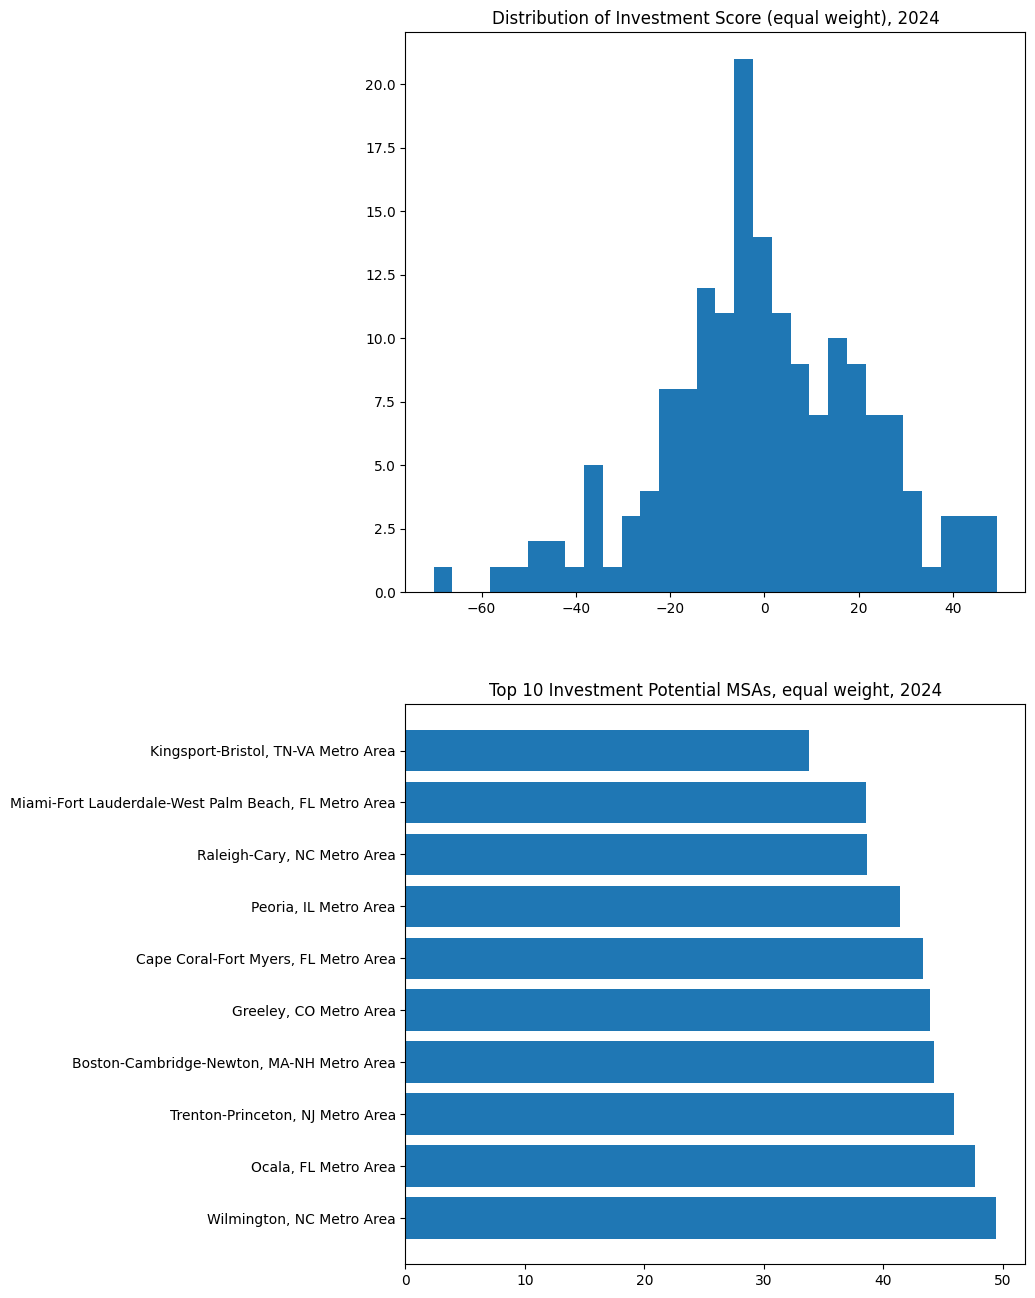

In [ ]:
factor_df_standardized_2024 = factor_df_standardized[factor_df_standardized['year']==2024].sort_values("Investment_Score", ascending=False)
factor_df_standardized_2024_top10 = factor_df_standardized_2024.head(10)


fig=plt.figure(figsize=(8,16))

ax1=fig.add_subplot(2,1,1)
ax1.hist(factor_df_standardized[factor_df_standardized['year']==2024]['Investment_Score'], bins=30)
ax1.set_title("Distribution of Investment Score (equal weight), 2024")

ax2=fig.add_subplot(2,1,2)
ax2.barh(factor_df_standardized_2024_top10['msa_name'], factor_df_standardized_2024_top10['Investment_Score'])
ax2.set_title("Top 10 Investment Potential MSAs, equal weight, 2024")

plt.show()

#New Index Scoring test


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ---------------------------
# Load Data
# ---------------------------
df = pd.read_excel("hotelshift_factors.xlsx")

# Use only the latest year (Investment decision logic)
latest_year = df["year"].max()
df = df[df["year"] == latest_year].copy()

print("Using Year:", latest_year)

# ---------------------------
# 1. Directional Correction (Converting all to "Higher is Better")
# ---------------------------

# Risk variables -> Negated
df["Vacancy_Rate_adj"] = -df["Vacancy_Rate"]
df["Rent_to_Income_adj"] = -df["Rent_to_Income_Ratio"]

# ---------------------------
# 2. Define Six Dimensional Variables
# ---------------------------

# 1. Economic Momentum
economic_vars = [
    "Employment_Growth",
    "Pop_Growth",
    "Income_Growth",
    "Employment_Rate"
]

# 2. Affordability & Stability
stability_vars = [
    "Rent_to_Income_adj",
    "Vacancy_Rate_adj"
]

# 3. Supply Pressure
supply_vars = [
    "Market_Tightness"
]

# 4. Pricing Power
pricing_vars = [
    "Rent_Growth"
]

# 5. Relative Valuation
valuation_vars = [
    "Implied_Value",
    "Value_Potential"
]

# 6. Capital Market / Risk Premium
capital_vars = [
    "Cap Spread",
    "Diff_Effective_Rate"
]

# ---------------------------
# 3. Standardization
# ---------------------------

scaler = StandardScaler()

all_vars = (
    economic_vars +
    stability_vars +
    supply_vars +
    pricing_vars +
    valuation_vars +
    capital_vars
)

df_scaled = df.copy()
df_scaled[all_vars] = scaler.fit_transform(df_scaled[all_vars])

# ---------------------------
# 4. Create Sub-Indices
# ---------------------------

df_scaled["Economic_Index"] = df_scaled[economic_vars].mean(axis=1)
df_scaled["Stability_Index"] = df_scaled[stability_vars].mean(axis=1)
df_scaled["Supply_Index"] = df_scaled[supply_vars].mean(axis=1)
df_scaled["Pricing_Index"] = df_scaled[pricing_vars].mean(axis=1)
df_scaled["Valuation_Index"] = df_scaled[valuation_vars].mean(axis=1)
df_scaled["Capital_Index"] = df_scaled[capital_vars].mean(axis=1)

# ---------------------------
# 5. Weighted Total Score
# (You can explain the weighting logic in your report)
# ---------------------------

df_scaled["Index_Score"] = (
    0.25 * df_scaled["Economic_Index"] +
    0.15 * df_scaled["Stability_Index"] +
    0.15 * df_scaled["Supply_Index"] +
    0.15 * df_scaled["Pricing_Index"] +
    0.20 * df_scaled["Valuation_Index"] +
    0.10 * df_scaled["Capital_Index"]
)

# ---------------------------
# 6. Ranking
# ---------------------------

ranking = df_scaled.sort_values("Index_Score", ascending=False)

print("\nTop 10 Markets:")
print(
    ranking[["msa_code", "msa_name", "Index_Score"]]
    .head(10)
    .reset_index(drop=True)
)

Using Year: 2024

Top 10 Markets:
   msa_code                                   msa_name  Index_Score
0     45940           Trenton-Princeton, NJ Metro Area     1.032285
1     43620              Sioux Falls, SD-MN Metro Area     0.781574
2     37900                      Peoria, IL Metro Area     0.776879
3     23060                  Fort Wayne, IN Metro Area     0.626394
4     29540                   Lancaster, PA Metro Area     0.564123
5     24540                     Greeley, CO Metro Area     0.530788
6     30700                     Lincoln, NE Metro Area     0.516597
7     31540                     Madison, WI Metro Area     0.507847
8     49340                   Worcester, MA Metro Area     0.507755
9     14460  Boston-Cambridge-Newton, MA-NH Metro Area     0.501120


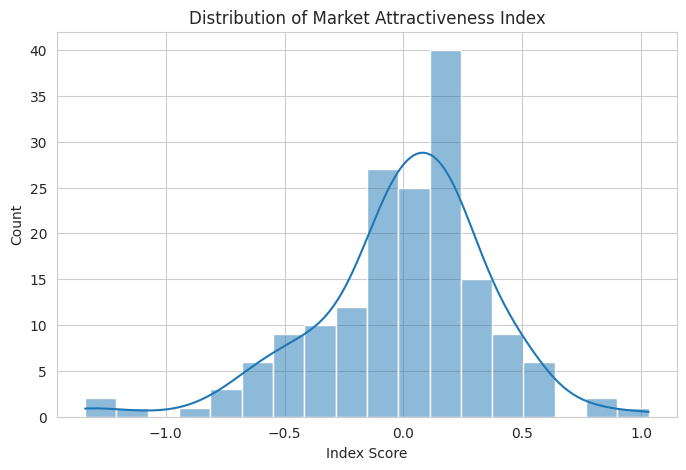

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_scaled["Index_Score"], kde=True)

plt.title("Distribution of Market Attractiveness Index")
plt.xlabel("Index Score")
plt.show()

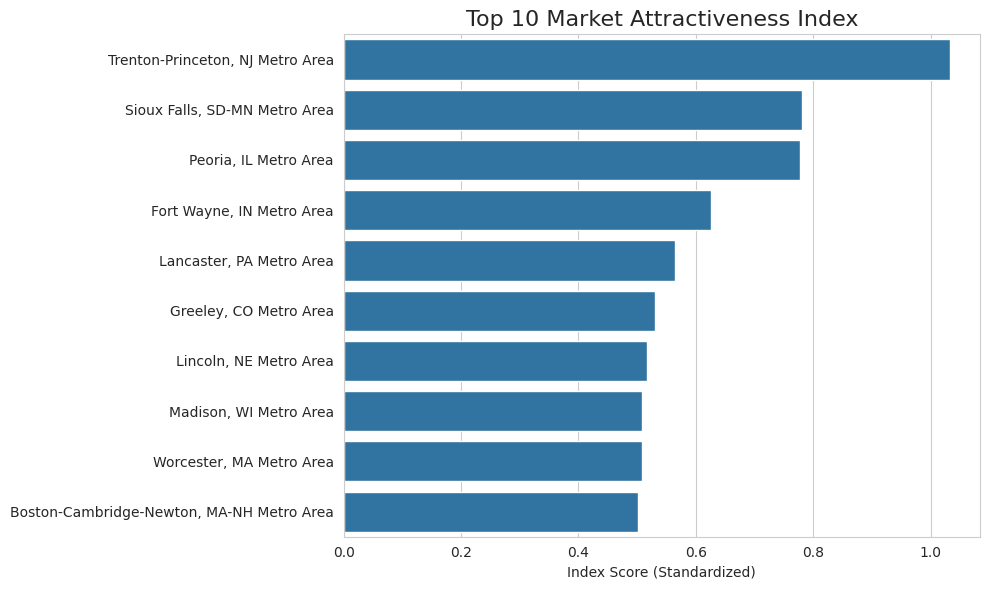

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# top 10
top10 = ranking.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Index_Score",
    y="msa_name"
)

plt.title("Top 10 Market Attractiveness Index", fontsize=16)
plt.xlabel("Index Score (Standardized)")
plt.ylabel("")
plt.tight_layout()
plt.show()

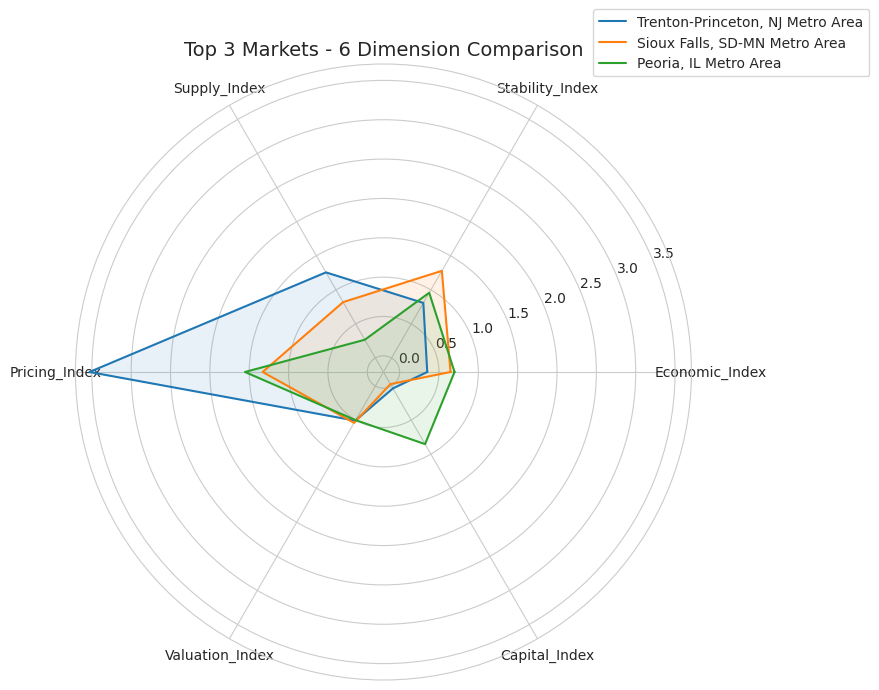

In [ ]:
import numpy as np

#top 3
top3 = ranking.head(3)

categories = [
    "Economic_Index",
    "Stability_Index",
    "Supply_Index",
    "Pricing_Index",
    "Valuation_Index",
    "Capital_Index"
]

N = len(categories)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for i in range(3):
    values = top3.iloc[i][categories].tolist()
    values += values[:1]
    ax.plot(angles, values, label=top3.iloc[i]["msa_name"])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.title("Top 3 Markets - 6 Dimension Comparison", size=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

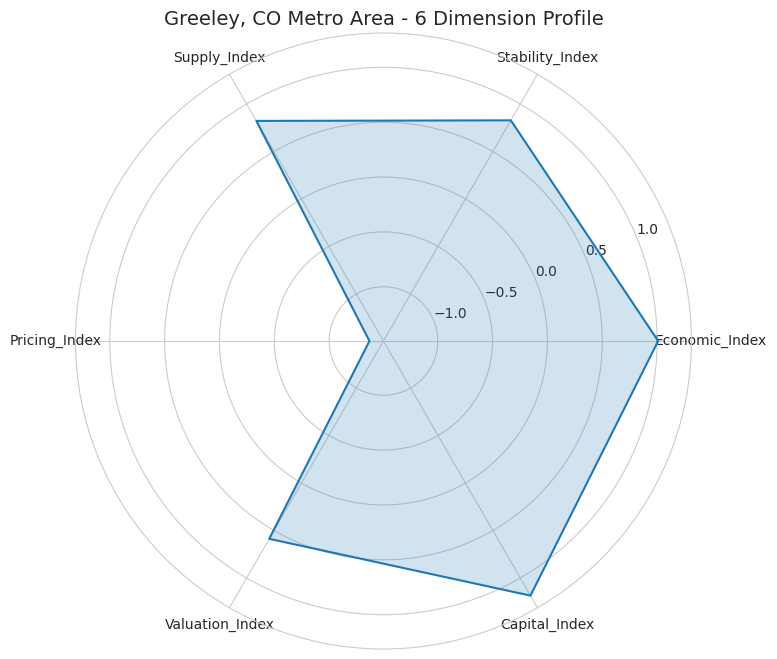

In [ ]:
# ================================
# Single MSA Radar Chart (by msa_code)
# ================================

import numpy as np
import matplotlib.pyplot as plt

# 🔹 Change this to the msa_code you want to visualize
target_code = 24540

# Six dimensions (consistent with the previous indexing)
categories = [
    "Economic_Index",
    "Stability_Index",
    "Supply_Index",
    "Pricing_Index",
    "Valuation_Index",
    "Capital_Index"
]

# Extract data for the specific market
msa_data = df_scaled[df_scaled["msa_code"] == target_code]

if msa_data.empty:
    print("msa_code not found, please check if it exists.")
else:
    msa_name = msa_data.iloc[0]["msa_name"]
    values = msa_data.iloc[0][categories].tolist()

    # Radar chart setup
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

    # Complete the loop for the radar chart
    angles += angles[:1]
    values += values[:1]

    plt.figure(figsize=(8,8))
    ax = plt.subplot(111, polar=True)

    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.2)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)

    plt.title(f"{msa_name} - 6 Dimension Profile", size=14)
    plt.show()